In [1]:
import numpy as np

In [2]:
class CubicSpline:
    def __init__(self, x, y):
        self.x = np.array(x, dtype=float)
        self.y = np.array(y, dtype=float)
        self.n = len(x) - 1
        
        self.h = self.x[1:] - self.x[:-1]
        self._build()

    def _build(self):
        n = self.n
        h = self.h
        y = self.y

        # --- 三重対角行列の構築 ---
        A = np.zeros((n+1, n+1))
        rhs = np.zeros(n+1)

        A[0,0] = 1
        A[n,n] = 1  # natural boundary

        for i in range(1, n):
            A[i,i-1] = h[i-1]
            A[i,i]   = 2*(h[i-1] + h[i])
            A[i,i+1] = h[i]
            
            rhs[i] = 6*((y[i+1]-y[i])/h[i]
                       - (y[i]-y[i-1])/h[i-1])

        # --- 二階微分 M を解く ---
        M = np.linalg.solve(A, rhs)

        # --- 係数計算 ---
        self.a = y[:-1]
        self.b = np.zeros(n)
        self.c = M[:-1] / 2
        self.d = np.zeros(n)

        for i in range(n):
            self.b[i] = ((y[i+1]-y[i])/h[i]
                        - h[i]*(2*M[i]+M[i+1])/6)
            self.d[i] = (M[i+1]-M[i])/(6*h[i])

    def __call__(self, xp):
        xp = np.asarray(xp)
        result = np.zeros_like(xp, dtype=float)

        for idx, val in np.ndenumerate(xp):
            i = np.searchsorted(self.x, val) - 1
            i = max(0, min(i, self.n-1))

            dx = val - self.x[i]
            result[idx] = (self.a[i]
                          + self.b[i]*dx
                          + self.c[i]*dx**2
                          + self.d[i]*dx**3)
        return result

    def derivative(self, xp):
        xp = np.asarray(xp)
        result = np.zeros_like(xp, dtype=float)

        for idx, val in np.ndenumerate(xp):
            i = np.searchsorted(self.x, val) - 1
            i = max(0, min(i, self.n-1))

            dx = val - self.x[i]
            result[idx] = (self.b[i]
                          + 2*self.c[i]*dx
                          + 3*self.d[i]*dx**2)
        return result

    def second_derivative(self, xp):
        xp = np.asarray(xp)
        result = np.zeros_like(xp, dtype=float)

        for idx, val in np.ndenumerate(xp):
            i = np.searchsorted(self.x, val) - 1
            i = max(0, min(i, self.n-1))

            dx = val - self.x[i]
            result[idx] = (2*self.c[i]
                          + 6*self.d[i]*dx)
        return result

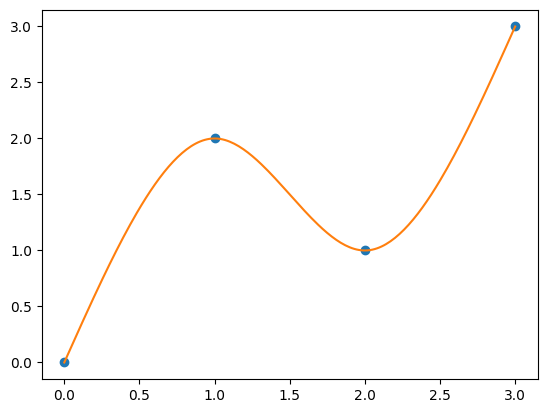

In [3]:
import matplotlib.pyplot as plt

x = [0, 1, 2, 3]
y = [0, 2, 1, 3]

cs = CubicSpline(x, y)

xx = np.linspace(0, 3, 200)
yy = cs(xx)

plt.plot(x, y, 'o')
plt.plot(xx, yy)
plt.show()